# Drone-embedding explorer

Explore the generator's learned per-drone embedding manifold two ways, both driven
by **one shared display core** (edit `plot_compare` / `render` / `show` in the CORE
cell and every view below updates):

1. **α slider** — interpolate/extrapolate along the drone-identity axis
   (`z_michaels − z_dregon`), rendered on a real RPS trajectory.
2. **2D draggable plane** — the same α axis (x) plus an orthogonal *novelty* axis (y)
   from a vicinal `z+ε` cloud. `(α, y) → 16-D z` is exact & invertible (tSNE/UMAP
   have no inverse, so they can't be dragged *back* — hence a PCA-derived basis).

α-interpolation is literally the `y=0` line of the plane, so both call `z_at(α, y)`.
Each render shows real-vs-generated **spectrograms + time-averaged spectra** (peak
positions / heights) + audio. Auto-loads the per-drone-σ run if present, else the
`jitter_latreg` winner.

In [8]:
# === setup: model + learned codes/linewidths =====================================
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "src"))
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Audio, display, clear_output
from data_processing.dregon import load_dregon_timeframes
from data_processing.michaels import load_michaels_timeframes
from data_processing.frames import get_meta
from data_processing.online_mixing import _extract_audio_array, interpolate_rps_to_stft_grid
from models.registry import build_noise_gen_model
from tasks.noise_generation import geometry_to_rel_pos

SR = 16000; DEVICE = "cpu"; DRONES = ["dregon", "michaels"]
_pd = PROJECT_ROOT/"omnirun-outputs/r2-artifacts/e6_noisegen_jitter_latreg_perdrone_best.ckpt"
_wn = PROJECT_ROOT/"omnirun-outputs/r2-artifacts/e6_noisegen_jitter_latreg_best.ckpt"
CKPT = _pd if _pd.exists() else _wn
sd = torch.load(CKPT, map_location=DEVICE, weights_only=False)
has_pd = any(k.startswith("log_jitter_sigma") for k in sd)
bk = dict(rps_jitter_sigma=0.6, rps_jitter_tau=0.016, z_noise_std=0.1, film_spectral_norm=True)
if has_pd: bk["learn_rps_jitter_sigma"] = True
model = build_noise_gen_model("positional_harmonic_gen", sample_rate=SR, n_harmonics=100,
                              cond_dim=16, drone_names=DRONES, **bk).to(DEVICE).eval()
model.load_state_dict(sd, strict=True)
Z   = {d: model.codebook.codes[d].detach().cpu().numpy() for d in DRONES}
SIG = {d: (F.softplus(model.log_jitter_sigma[d]).item() if has_pd else 0.6) for d in DRONES}
print("checkpoint:", CKPT.name, "| per-drone σ:", "yes" if has_pd else "no (0.6)", "| σ:",
      {k: round(v,3) for k,v in SIG.items()})

checkpoint: e6_noisegen_jitter_latreg_best.ckpt | per-drone σ: no (0.6) | σ: {'dregon': 0.6, 'michaels': 0.6}


In [9]:
# === real RPS windows to condition on (highest mean RPS ⇒ in-flight) =============
_dr = load_dregon_timeframes(PROJECT_ROOT/"data", splits=["in_flight_noise"], target_sr=SR, download=False)
_mi = load_michaels_timeframes(data_root=PROJECT_ROOT/"data", sr=SR)
REC = {f"dregon:{get_meta(tf,'recording_id')}": tf for tf in _dr}
REC |= {f"michaels:FLY{get_meta(tf,'recording_id')}": tf for tf in _mi}

def _pick(rec_id, dur_s, stride_s=2.0):
    tf = REC[rec_id]; t0 = tf["audio"].t_start; avail = tf["audio"].t_end - t0
    bs, bm, s = 0.0, -1.0, 0.0
    while s + dur_s <= avail:
        m = float(interpolate_rps_to_stft_grid(tf.time[t0+s:t0+s+dur_s], n_frames=16,
                                               hop_length=int(dur_s*SR/16)).mean())
        if m > bm: bs, bm = s, m
        s += stride_s
    return bs

def _load_window(rec_id, mic=0, dur_s=4.0):
    tf = REC[rec_id]; t0 = tf["audio"].t_start; s = _pick(rec_id, dur_s)
    sl = tf.time[t0+s:t0+s+dur_s]; n = int(round(dur_s*SR))
    tgt = _extract_audio_array(sl, target_len=n)
    rps = interpolate_rps_to_stft_grid(sl, n_frames=n, hop_length=1)
    rel = geometry_to_rel_pos(sl["mic_pos"].data, sl["rotor_pos"].data)
    mic = min(mic, tgt.shape[0]-1)
    return dict(rec_id=rec_id, real=tgt[mic], rps=rps, rel=rel[mic:mic+1])

_drid = next((r for r in REC if r.startswith("dregon:free-flight")), next(r for r in REC if r.startswith("dregon:")))
_miid = next((r for r in REC if r.startswith("michaels:FLY125")), next(r for r in REC if r.startswith("michaels:")))
WIN = {"DREGON path": _load_window(_drid), "Michael's path": _load_window(_miid)}
print("windows:", {k: v["rec_id"] for k, v in WIN.items()})

windows: {'DREGON path': 'dregon:free-flight_nosource_room1', "Michael's path": 'michaels:FLY125'}


/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/data_processing/michaels.py:144: DtypeWarning: Columns (49,50,211,215,216,217,227) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv(csv_path)


In [10]:
# === embedding geometry: (α, y) → 16-D z  (exact & invertible) ===================
zd, zm = Z["dregon"], Z["michaels"]
d = zm - zd; L = float(np.linalg.norm(d)); dhat = d / L; c = (zd + zm) / 2
rms = float(np.mean([np.sqrt((z**2).mean()) for z in Z.values()])); REL_STD = 0.15
_rng = np.random.default_rng(0)
cloud = np.array([z + _rng.normal(size=z.shape)*(REL_STD*np.sqrt((z**2).mean()))
                  for z in (zd, zm) for _ in range(40)])
_res = (cloud - c) - ((cloud - c) @ dhat)[:, None] * dhat[None, :]   # strip drone-axis part
ehat = np.linalg.svd(_res, full_matrices=False)[2][0]               # top orthogonal dir
YSCALE = REL_STD * rms

def z_at(alpha, y=0.0):        # α: 0=dregon, 1=michaels;  y: novelty in vicinal-σ units
    return c + (alpha - 0.5) * L * dhat + y * YSCALE * ehat
def plane_of(z):
    return (0.5 + float((z - c) @ dhat) / L, float((z - c) @ ehat) / YSCALE)
def sigma_at(alpha):
    return max(0.0, (1 - alpha) * SIG["dregon"] + alpha * SIG["michaels"])

CLOUD_XY = np.array([plane_of(z) for z in cloud]); XY = {dn: plane_of(Z[dn]) for dn in DRONES}
print("dhat·ehat =", round(float(dhat @ ehat), 9), "| dregon", tuple(round(v,2) for v in XY['dregon']),
      "michaels", tuple(round(v,2) for v in XY['michaels']))

dhat·ehat = 1.1e-08 | dregon (0.0, -0.0) michaels (1.0, 0.0)


In [ ]:
%matplotlib widget
# === CORE display — EDIT HERE; every view routes through these ==================
import ipywidgets as widgets

def stft_mag(x, n_fft=1024, hop=256):
    return torch.stft(torch.from_numpy(np.ascontiguousarray(x)).float(), n_fft=n_fft, hop_length=hop,
                      window=torch.hann_window(n_fft), return_complex=True).abs().numpy()  # (F, T)
def logspec(x):      return 20*np.log10(stft_mag(x) + 1e-6)
def mean_spec_db(x): return 20*np.log10(stft_mag(x).mean(1) + 1e-6)
FREQS = np.linspace(0, SR/2, 1024//2 + 1)

def spec_from_mag(X):
    """avg or single-frame column of a magnitude STFT (F,T) -> dB, per SPEC."""
    if SPEC['mode'] == 'frame':
        f = int(np.clip(round(SPEC['t']*SR/256), 0, X.shape[1]-1)); return 20*np.log10(X[:, f] + 1e-6)
    return 20*np.log10(X.mean(1) + 1e-6)

def render(z, sigma, path, seed=0):
    """Arbitrary code z (16,) + linewidth σ on a real trajectory → mono noise (T,)."""
    z = torch.as_tensor(z, dtype=torch.float32, device=DEVICE); w = WIN[path]; torch.manual_seed(seed)
    with torch.no_grad():
        return model.generator(
            torch.from_numpy(w["rps"])[None].float().to(DEVICE),
            torch.from_numpy(w["rel"])[None].float().to(DEVICE),
            z=z[None], rps_jitter=True,
            rps_jitter_sigma=torch.tensor([max(0.0, float(sigma))], device=DEVICE))[0, 0].cpu().numpy()

# Spectrum mode shared by ALL views: "avg" (time-averaged) or "frame" @ SPEC["t"] seconds.
SPEC = {"mode": "avg", "t": 0.0}
_CUR = {"cmp": None}                       # most-recent Compare (what the toggle redraws)
spec_mode = widgets.ToggleButtons(options=["avg", "frame"], value="avg", description="spectrum:")

class Compare:
    """real|gen spectrograms (top) + their spectra (bottom): time-averaged, or the
    single time frame you click on a spectrogram. Toggle avg/frame; frame persists
    across renders so you can pin a time and sweep α."""
    HOP = 256
    def __init__(self, real, gen, rtitle, gtitle):
        _CUR["cmp"] = self
        self.Xr, self.Xg = stft_mag(real, hop=self.HOP), stft_mag(gen, hop=self.HOP)
        self.dur = real.shape[-1] / SR
        Sr, Sg = 20*np.log10(self.Xr + 1e-6), 20*np.log10(self.Xg + 1e-6)
        vmax = Sr.max(); vmin = vmax - 80
        self.fig, self.ax = plt.subplots(2, 2, figsize=(9.5, 5.8), gridspec_kw=dict(height_ratios=[2, 1.3]))
        try: self.fig.canvas.header_visible = False
        except Exception: pass
        for a, S, ttl in [(self.ax[0,0], Sr, rtitle), (self.ax[0,1], Sg, gtitle)]:
            a.imshow(S, origin="lower", aspect="auto", vmin=vmin, vmax=vmax, cmap="magma", extent=[0, self.dur, 0, SR/2])
            a.set_title(ttl, fontsize=10); a.set_xlabel("s")
        self.ax[0,0].set_ylabel("Hz")
        self.cur = [self.ax[0,0].axvline(0, c="cyan", lw=1.2, alpha=0),
                    self.ax[0,1].axvline(0, c="cyan", lw=1.2, alpha=0)]
        self.fig.canvas.mpl_connect("button_press_event", self._click)
        self.redraw(); plt.tight_layout(); plt.show()
        display(Audio(gen, rate=SR, normalize=True))
    def _col(self, X):
        return spec_from_mag(X)
    def redraw(self):
        mr, mg = self._col(self.Xr), self._col(self.Xg)
        ylo, yhi = min(mr.min(), mg.min()), max(mr.max(), mg.max())
        tag = f"@ {SPEC['t']:.2f}s" if SPEC["mode"] == "frame" else "(avg)"
        for j, (m, other, ttl, col) in enumerate([(mr, mg, f"real spectrum {tag}", "tab:blue"),
                                                   (mg, mr, f"gen spectrum {tag}", "tab:red")]):
            a = self.ax[1, j]; a.clear()
            a.plot(FREQS, other, lw=0.8, c="0.65", alpha=0.7)   # counterpart (grey reference)
            a.plot(FREQS, m, lw=1.1, c=col)
            a.set_xlim(0, SR/2); a.set_ylim(ylo-2, yhi+3)
            a.set_xlabel("Hz"); a.set_title(ttl, fontsize=9); a.grid(alpha=0.25)
        self.ax[1,0].set_ylabel("dB")
        vis = SPEC["mode"] == "frame"
        for cl in self.cur: cl.set_xdata([SPEC["t"], SPEC["t"]]); cl.set_alpha(0.9 if vis else 0)
        self.fig.canvas.draw_idle()
    def _click(self, ev):
        if ev.inaxes in (self.ax[0,0], self.ax[0,1]) and ev.xdata is not None:
            SPEC["t"] = float(ev.xdata)
            if spec_mode.value != "frame": spec_mode.value = "frame"   # observer redraws _CUR
            else: SPEC["mode"] = "frame"; self.redraw()

def _on_spec_mode(ch):
    SPEC["mode"] = ch["new"]
    if _CUR["cmp"] is not None: _CUR["cmp"].redraw()
spec_mode.observe(_on_spec_mode, "value")

def plot_compare(real, gen, rtitle, gtitle):
    Compare(real, gen, rtitle, gtitle)

def show(alpha, y, path):
    """The one call both views use: (α, y, path) → render + compare + play."""
    plot_compare(WIN[path]["real"], render(z_at(alpha, y), sigma_at(alpha), path),
                 f"REAL ({path.split()[0]})", f"GEN  α={alpha:.2f}  y={y:.2f}  σ={sigma_at(alpha):.2f}")

# --- component decomposition: harmonic bank vs broadband residual, per rotor -----
from models.generative.positional_harmonic_gen import propagate as _propagate

def render_components(z, sigma, path, seed=0):
    """Split the generated noise into harmonic vs broadband, PER ROTOR, at the mic.
    The emitter makes each rotor's harmonic oscillator bank (`harm_noise`) and its
    filtered-broadband residual (`diff_noise`) separately; propagation is linear so
    each is rendered to the mic on its own. total == harm + broad exactly."""
    w = WIN[path]; g = model.generator
    rps = torch.from_numpy(w["rps"])[None].float().to(DEVICE)   # [1, R, T]
    rel = torch.from_numpy(w["rel"])[None].float().to(DEVICE)   # [1, 1, R, 3] (single mic)
    b, R, T = rps.shape
    z = torch.as_tensor(z, dtype=torch.float32, device=DEVICE)
    folded = rps.reshape(b*R, 1, T)
    z_folded = z[None].repeat_interleave(R, dim=0)
    sig_folded = torch.full((b*R,), max(0.0, float(sigma)), device=DEVICE)
    torch.manual_seed(seed)
    with torch.no_grad():
        out = g.emitter(folded, z=z_folded, rps_jitter=True, rps_jitter_sigma=sig_folded, return_dict=True)
        harm  = out["harm_noise"].sum(-2).reshape(b, R, T)   # [1, R, T] (sum over the 1 oscillator)
        broad = out["diff_noise"].reshape(b, R, T)           # [1, R, T]
        def obs(src, rsrc):                                  # [1, r, T] -> mic (T,)
            return _propagate(src, rsrc, sample_rate=SR, c=g.speed_of_sound,
                              ref_distance=g.ref_distance, eps=g.eps)[0, 0].cpu().numpy()
        comps = {"harm":  obs(harm, rel), "broad": obs(broad, rel),
                 "harm_r":  [obs(harm[:, r:r+1],  rel[:, :, r:r+1]) for r in range(R)],
                 "broad_r": [obs(broad[:, r:r+1], rel[:, :, r:r+1]) for r in range(R)]}
    comps["total"] = comps["harm"] + comps["broad"]
    return comps

class Decompose:
    """Total gen spectrogram (click to pin a frame) + spectra: real vs total vs
    harmonic-sum vs broadband-sum, then one panel per rotor (its harmonic comb vs
    its broadband). Respects the avg/frame toggle; harmonic-only & broadband-only
    audio at the bottom."""
    HOP = 256
    def __init__(self, real, comps, title):
        _CUR["cmp"] = self
        self.real, self.comps, self.title = real, comps, title
        self.R = len(comps["harm_r"]); self.dur = real.shape[-1] / SR
        M = lambda x: stft_mag(x, hop=self.HOP)
        self.mag = {"real": M(real), "total": M(comps["total"]), "harm": M(comps["harm"]),
                    "broad": M(comps["broad"]), "harm_r": [M(h) for h in comps["harm_r"]],
                    "broad_r": [M(b) for b in comps["broad_r"]]}
        nrow = 1 + (self.R + 1) // 2
        self.fig = plt.figure(figsize=(10.5, 3.0 + 2.4*(nrow-1)))
        try: self.fig.canvas.header_visible = False
        except Exception: pass
        gs = self.fig.add_gridspec(nrow, 2)
        self.ax_spec = self.fig.add_subplot(gs[0, 0])
        S = 20*np.log10(self.mag["total"] + 1e-6); vmax = S.max()
        self.ax_spec.imshow(S, origin="lower", aspect="auto", vmin=vmax-80, vmax=vmax, cmap="magma",
                            extent=[0, self.dur, 0, SR/2])
        self.ax_spec.set_title("gen total (click to pin frame)", fontsize=9)
        self.ax_spec.set_xlabel("s"); self.ax_spec.set_ylabel("Hz")
        self.cur = self.ax_spec.axvline(0, c="cyan", lw=1.2, alpha=0)
        self.ax_sum = self.fig.add_subplot(gs[0, 1])
        self.ax_rot = [self.fig.add_subplot(gs[1 + r//2, r % 2]) for r in range(self.R)]
        self.fig.canvas.mpl_connect("button_press_event", self._click)
        self.redraw(); self.fig.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()
        for lbl, key in [("total", "total"), ("harmonic only", "harm"), ("broadband only", "broad")]:
            print(lbl + ":"); display(Audio(comps[key], rate=SR, normalize=True))
    def _spec(self, key, idx=None):
        return spec_from_mag(self.mag[key] if idx is None else self.mag[key][idx])
    def redraw(self):
        rr, tt, hh, bb = (self._spec("real"), self._spec("total"), self._spec("harm"), self._spec("broad"))
        ylo = min(x.min() for x in (rr, tt, hh, bb)); yhi = max(x.max() for x in (rr, tt, hh, bb))
        tag = f"@ {SPEC['t']:.2f}s" if SPEC["mode"] == "frame" else "(avg)"
        a = self.ax_sum; a.clear()
        a.plot(FREQS, rr, lw=1.0, c="0.5", label="real")
        a.plot(FREQS, tt, lw=0.9, c="k", ls="--", label="gen total")
        a.plot(FREQS, hh, lw=1.2, c="tab:green", label="harmonic Σ")
        a.plot(FREQS, bb, lw=1.2, c="tab:orange", label="broadband Σ")
        a.set_title(f"real vs components {tag}", fontsize=9); a.set_xlim(0, SR/2); a.set_ylim(ylo-2, yhi+3)
        a.set_xlabel("Hz"); a.set_ylabel("dB"); a.grid(alpha=0.25); a.legend(fontsize=7, ncol=2)
        for r in range(self.R):
            a = self.ax_rot[r]; a.clear()
            a.plot(FREQS, rr, lw=0.6, c="0.7", alpha=0.6)
            a.plot(FREQS, self._spec("harm_r", r), lw=1.1, c="tab:green")
            a.plot(FREQS, self._spec("broad_r", r), lw=1.1, c="tab:orange")
            a.set_title(f"rotor {r}: harmonic vs broadband", fontsize=8)
            a.set_xlim(0, SR/2); a.set_ylim(ylo-2, yhi+3); a.set_xlabel("Hz"); a.grid(alpha=0.25)
        self.cur.set_xdata([SPEC["t"], SPEC["t"]]); self.cur.set_alpha(0.9 if SPEC["mode"] == "frame" else 0)
        self.fig.canvas.draw_idle()
    def _click(self, ev):
        if ev.inaxes is self.ax_spec and ev.xdata is not None:
            SPEC["t"] = float(ev.xdata)
            if spec_mode.value != "frame": spec_mode.value = "frame"
            else: SPEC["mode"] = "frame"; self.redraw()

def decompose_show(alpha, y, path):
    comps = render_components(z_at(alpha, y), sigma_at(alpha), path)
    Decompose(WIN[path]["real"], comps, f"α={alpha:.2f}  y={y:.2f}  —  {path}")
print("core ready — click a spectrogram to pin a time frame; avg/frame toggle switches back")

## Sanity — the two real drones (α=0, α=1) on their own paths

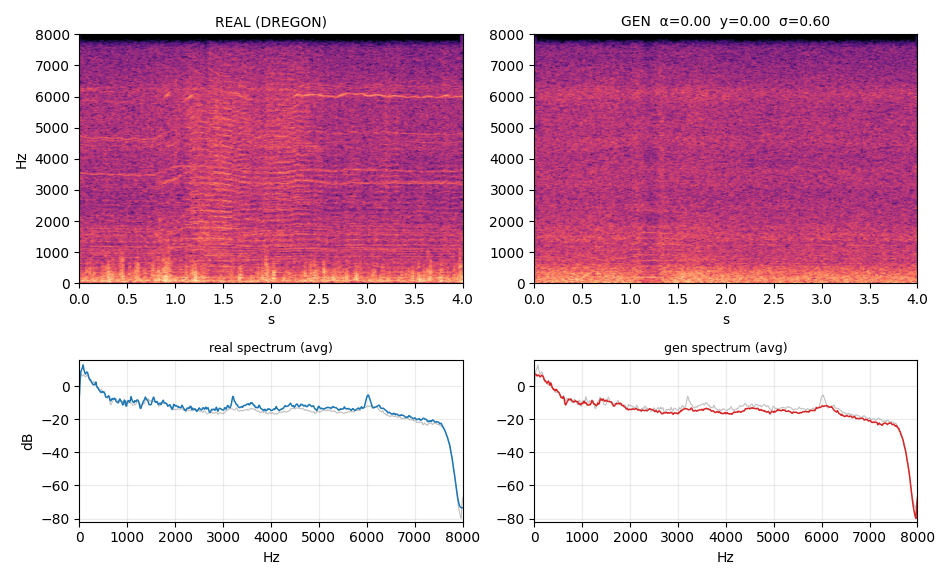

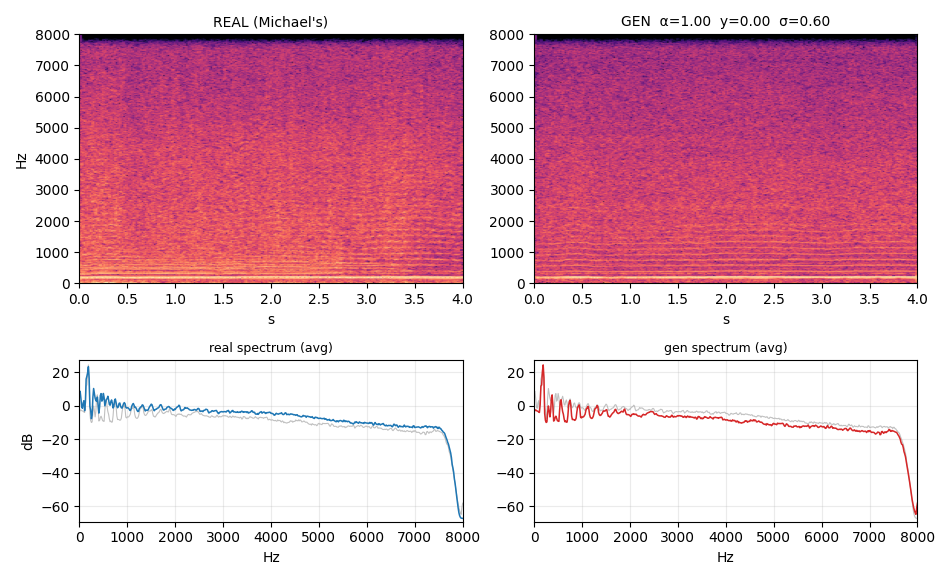

In [12]:
show(0.0, 0.0, "DREGON path")      # dregon code on the dregon trajectory
show(1.0, 0.0, "Michael's path")   # michaels code on the michaels trajectory

## View 1 — α slider (interpolate / extrapolate the drone axis)

In [13]:
_o1 = widgets.Output()
def _v1(alpha, path):
    with _o1: clear_output(wait=True); show(alpha, 0.0, path)
_a = widgets.FloatSlider(value=0.5, min=-0.5, max=1.5, step=0.05, description="α", continuous_update=False)
_p = widgets.Dropdown(options=list(WIN), description="path")
display(widgets.HBox([_a, _p, spec_mode]), _o1)
widgets.interactive_output(_v1, {"alpha": _a, "path": _p}); _v1(0.5, "DREGON path")

Output()

## View 2 — drag the point on the 2D embedding plane
x = α (drone identity), y = orthogonal novelty (vicinal cloud in grey). Release the
mouse to render + play; toggle which real path conditions the RPS.

Output()

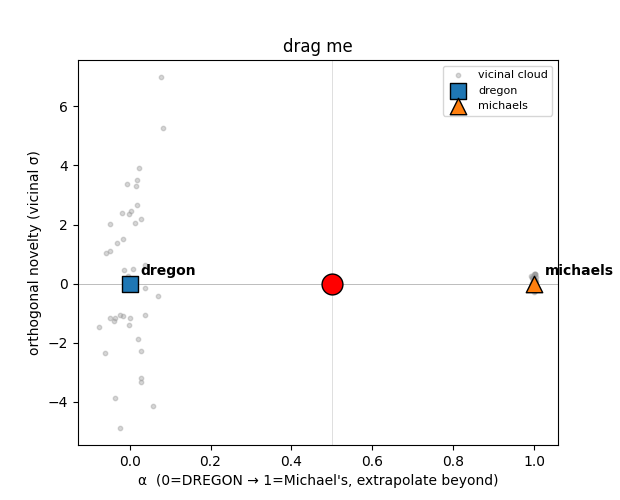

In [14]:
_st = {"xy": (0.5, 0.0), "drag": False}
_o2 = widgets.Output()
_ptb = widgets.ToggleButtons(options=list(WIN), value="DREGON path", description="RPS path:")

_fig, _ax = plt.subplots(figsize=(6.2, 5.0))
try: _fig.canvas.header_visible = False
except Exception: pass
_ax.scatter(CLOUD_XY[:,0], CLOUD_XY[:,1], s=10, c="0.6", alpha=0.4, label="vicinal cloud")
for dn, mk, cl in [("dregon","s","tab:blue"), ("michaels","^","tab:orange")]:
    _ax.scatter(*XY[dn], s=140, marker=mk, c=cl, edgecolor="k", zorder=4, label=dn)
    _ax.annotate(dn, XY[dn], textcoords="offset points", xytext=(8,6), fontweight="bold")
_ax.axhline(0, lw=0.6, c="k", alpha=0.3); _ax.axvline(0.5, lw=0.6, c="k", alpha=0.15)
(_mk,) = _ax.plot([0.5], [0.0], "o", ms=15, c="red", mec="k", zorder=6)
_ax.set_xlabel("α  (0=DREGON → 1=Michael's, extrapolate beyond)")
_ax.set_ylabel("orthogonal novelty (vicinal σ)"); _ax.set_title("drag me"); _ax.legend(loc="upper right", fontsize=8)

def _draw(): _mk.set_data([_st["xy"][0]], [_st["xy"][1]]); _fig.canvas.draw_idle()
def _press(ev):
    if ev.inaxes is _ax and ev.xdata is not None: _st.update(drag=True, xy=(ev.xdata, ev.ydata)); _draw()
def _move(ev):
    if _st["drag"] and ev.inaxes is _ax and ev.xdata is not None: _st["xy"] = (ev.xdata, ev.ydata); _draw()
def _release(ev):
    if _st["drag"]:
        _st["drag"] = False
        with _o2: clear_output(wait=True); show(_st["xy"][0], _st["xy"][1], _ptb.value)
_fig.canvas.mpl_connect("button_press_event", _press)
_fig.canvas.mpl_connect("motion_notify_event", _move)
_fig.canvas.mpl_connect("button_release_event", _release)
def _on_path(ch):
    with _o2: clear_output(wait=True); show(_st["xy"][0], _st["xy"][1], _ptb.value)
_ptb.observe(_on_path, "value")
display(widgets.HBox([_ptb, spec_mode]), _o2)
with _o2: show(0.5, 0.0, "DREGON path")

## View 3 — harmonic vs broadband decomposition (per rotor)

Splits the generated noise into its harmonic-bank and broadband-residual parts, for each rotor. Click the *gen total* spectrogram to pin a frame (or use the avg/frame toggle). Compares real vs total vs harmonic-Σ vs broadband-Σ, then each rotor's comb vs its broadband — to see whether the harmonic peaks are simply weak and/or the broadband floor is too high. Harmonic-only / broadband-only audio at the bottom.

In [ ]:
_o3 = widgets.Output()
def _v3(alpha, path):
    with _o3: clear_output(wait=True); decompose_show(alpha, 0.0, path)
_a3 = widgets.FloatSlider(value=0.0, min=-0.5, max=1.5, step=0.05, description="α", continuous_update=False)
_p3 = widgets.Dropdown(options=list(WIN), value="DREGON path", description="path")
display(widgets.HBox([_a3, _p3, spec_mode]), _o3)
widgets.interactive_output(_v3, {"alpha": _a3, "path": _p3}); _v3(0.0, "DREGON path")

**Read-off:** near (α=0, y=0) / (α=1, y=0) it should match the real drone; the
mean-spectrum peaks should sit at the same rotor-harmonic frequencies as the real
recording and only their *heights* drift as you move; nudging y should stay a
plausible comb (that's what `z_noise` bought) before degrading far out.